In [1]:
import pandas as pd
import numpy as np
import warnings 
warnings.filterwarnings('ignore')

### 개요
- '24년도_따릉이_이용건수.csv'에서 2024년치 데이터를 불러오고 필요한 스테이션 정보만 추출
- 필요한 스테이션 번호는 ST-1035 / ST-454 / ST-471
- 추출한 데이터의 범위는 은평구 안에서만 움직인 데이터만 이용한다.


In [3]:
df = pd.read_csv('../../Data/Zero/Temp/24년도_따릉이_이용건수.csv')
df.drop('Unnamed: 0',axis=1,inplace=True)


In [16]:
df1 = pd.read_csv('../../Data/은평구_스테이션_군집화_1차_자전거댓수_추가.csv')
df1

,대여소_ID,주소1,주소2,위도,경도,1분기_전체건수,2분기_전체건수,3분기_전체건수,4분기_전체건수,연간_전체건수,cluster_12_custom,LCD,QR
0,ST-453,진관동 86-31,구파발역 2번출구,37.636234,126.918999,8392,19134,14804,10860,53190,1,11.0,10.0
1,ST-1483,진관2로 15-46,은평구 진관2로 15-46,37.639259,126.918907,3696,8120,6612,4986,23414,1,10.0,0.0
2,ST-1481,진관2로 지하 15-25,구파발역 환승센터,37.638252,126.919456,3112,6034,4838,4348,18332,1,15.0,0.0
3,ST-1329,진관3로 77,은평뉴타운구파발9단지,37.642609,126.921478,2696,5372,4268,3298,15634,1,10.0,0.0
4,ST-2244,진관4로 26 진관고등학교,NaN,37.643509,126.924103,2082,5474,4326,3502,15384,1,0.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,ST-462,신사동 352-2,NaN,37.590809,126.913689,10730,23348,15650,14046,63774,12,NaN,NaN
94,ST-463,증산동 199-8,증산역 4번출구,37.584381,126.909897,7233,12914,9790,8834,38771,12,10.0,0.0
95,ST-2257,가좌로 255,NaN,37.591812,126.914833,6633,13360,8368,7994,36355,12,0.0,10.0
96,ST-1034,증산동 239,디지털미디어 시티역 4번출구,37.577202,126.902351,3796,5736,4514,4626,18672,12,10.0,0.0


In [13]:
addr = df1['대여소_ID'].unique().tolist()
addr

['ST-453',
 'ST-1483',
 'ST-1481',
 'ST-1329',
 'ST-2244',
 'ST-450',
 'ST-3058',
 'ST-1480',
 'ST-1024',
 'ST-1023',
 'ST-459',
 'ST-1029',
 'ST-465',
 'ST-2253',
 'ST-2785',
 'ST-2250',
 'ST-1025',
 'ST-448',
 'ST-2956',
 'ST-2776',
 'ST-2246',
 'ST-1027',
 'ST-3126',
 'ST-2263',
 'ST-1039',
 'ST-2780',
 'ST-476',
 'ST-2781',
 'ST-2241',
 'ST-2245',
 'ST-3201',
 'ST-2242',
 'ST-1031',
 'ST-451',
 'ST-452',
 'ST-1028',
 'ST-1490',
 'ST-1489',
 'ST-2425',
 'ST-2252',
 'ST-2247',
 'ST-1674',
 'ST-3127',
 'ST-1020',
 'ST-454',
 'ST-1035',
 'ST-2782',
 'ST-470',
 'ST-471',
 'ST-475',
 'ST-1038',
 'ST-1485',
 'ST-2261',
 'ST-2824',
 'ST-1033',
 'ST-2783',
 'ST-3028',
 'ST-469',
 'ST-3095',
 'ST-3279',
 'ST-479',
 'ST-481',
 'ST-464',
 'ST-456',
 'ST-480',
 'ST-1036',
 'ST-3169',
 'ST-1482',
 'ST-2778',
 'ST-467',
 'ST-473',
 'ST-2470',
 'ST-1484',
 'ST-1032',
 'ST-1488',
 'ST-2262',
 'ST-1487',
 'ST-460',
 'ST-1331',
 'ST-461',
 'ST-2775',
 'ST-1479',
 'ST-2777',
 'ST-2825',
 'ST-478',
 'S

In [5]:
station = ['ST-1035','ST-454','ST-471']

In [ ]:
# station: 단일 값 또는 리스트 모두 처리
if isinstance(station, (list, tuple, set)):
    station_list = list(station)
else:
    station_list = [station]

# 시작 기준
df_start = df[df['시작_대여소_ID'].isin(station_list)].copy()

# 도착 기준
df_end = df[df['종료_대여소_ID'].isin(station_list)].copy()




(             기준_날짜 집계_기준 시작_대여소_ID     시작_대여소명 종료_대여소_ID      종료_대여소명  전체_건수  \
 476       20241102  출발시간    ST-471  불광1동_025_1    ST-461   응암1동_023_2    1.0   
 674       20241102  출발시간   ST-1035  불광2동_020_1    ST-456   갈현2동_014_1    1.0   
 1083      20241102  출발시간    ST-454   대조동_020_1   ST-2470   불광1동_018_2    1.0   
 1744      20241102  출발시간    ST-454   대조동_020_1   ST-3272   성산2동_017_1    1.0   
 2959      20241102  출발시간   ST-1035  불광2동_020_1    ST-350  북가좌1동_004_2    1.0   
 ...            ...   ...       ...         ...       ...          ...    ...   
 81608803  20240205  출발시간    ST-471  불광1동_018_1   ST-2956   응암1동_049_1    1.0   
 81609678  20240205  도착시간    ST-471  불광1동_018_1   ST-2956   응암1동_049_1    1.0   
 81610430  20240205  도착시간   ST-1035  불광2동_021_1   ST-2425   신사1동_036_1    1.0   
 81612436  20240205  출발시간   ST-1035  불광2동_021_1    ST-467    녹번동_001_3    1.0   
 81612665  20240205  도착시간   ST-1035  불광2동_021_1    ST-467    녹번동_001_3    1.0   
 
           전체_이용_분  전체_이용_

In [7]:
df_start

,기준_날짜,집계_기준,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,기준_시간
476,20241102,출발시간,ST-471,불광1동_025_1,ST-461,응암1동_023_2,1.0,18.0,3052.0,1240.0
674,20241102,출발시간,ST-1035,불광2동_020_1,ST-456,갈현2동_014_1,1.0,3.0,740.0,2350.0
1083,20241102,출발시간,ST-454,대조동_020_1,ST-2470,불광1동_018_2,1.0,7.0,1330.0,2200.0
1744,20241102,출발시간,ST-454,대조동_020_1,ST-3272,성산2동_017_1,1.0,35.0,5350.0,2055.0
2959,20241102,출발시간,ST-1035,불광2동_020_1,ST-350,북가좌1동_004_2,1.0,77.0,5884.0,1800.0
...,...,...,...,...,...,...,...,...,...,...
81608803,20240205,출발시간,ST-471,불광1동_018_1,ST-2956,응암1동_049_1,1.0,22.0,3080.0,1905.0
81609678,20240205,도착시간,ST-471,불광1동_018_1,ST-2956,응암1동_049_1,1.0,22.0,3080.0,1930.0
81610430,20240205,도착시간,ST-1035,불광2동_021_1,ST-2425,신사1동_036_1,1.0,80.0,4020.0,1955.0
81612436,20240205,출발시간,ST-1035,불광2동_021_1,ST-467,녹번동_001_3,1.0,12.0,1795.0,2125.0


In [8]:
df_end

,기준_날짜,집계_기준,시작_대여소_ID,시작_대여소명,종료_대여소_ID,종료_대여소명,전체_건수,전체_이용_분,전체_이용_거리,기준_시간
770,20241102,출발시간,ST-2167,서교동_008_1,ST-471,불광1동_025_1,1.0,55.0,7254.0,2210.0
2591,20241102,출발시간,ST-1038,불광2동_042_1,ST-1035,불광2동_020_1,1.0,3.0,505.0,820.0
3280,20241102,출발시간,ST-471,불광1동_025_1,ST-454,대조동_020_1,1.0,7.0,945.0,225.0
4159,20241102,출발시간,ST-1035,불광2동_020_1,ST-1035,불광2동_020_1,1.0,36.0,2311.0,1020.0
4985,20241102,출발시간,ST-33,북가좌2동_042_1,ST-454,대조동_020_1,1.0,33.0,3854.0,1845.0
...,...,...,...,...,...,...,...,...,...,...
81607578,20240205,도착시간,ST-454,대조동_024_1,ST-1035,불광2동_021_1,1.0,22.0,460.0,1835.0
81607580,20240205,도착시간,ST-481,구산동_062_1,ST-454,대조동_024_1,1.0,4.0,926.0,1835.0
81607809,20240205,도착시간,ST-448,녹번동_051_1,ST-1035,불광2동_021_1,1.0,33.0,410.0,1840.0
81613172,20240205,출발시간,ST-2263,진관동_108_6,ST-471,불광1동_018_1,1.0,9.0,1594.0,2200.0


In [15]:
# 1) capacity 만들기
df1['LCD'] = pd.to_numeric(df1['LCD'], errors='coerce').fillna(0)
df1['QR'] = pd.to_numeric(df1['QR'], errors='coerce').fillna(0)
df1['capacity'] = df1['LCD'] + df1['QR']

# 2) 시간대 만들기
df['기준_시간'] = df['기준_시간'].fillna(0).astype(int)
df['hour'] = (df['기준_시간'] // 100).astype(int)

# 3) 대여/반납 집계
# 집계_기준이 '출발시간'/'도착시간' 있는 경우
start_df = df[df['집계_기준'].astype(str).str.contains('출발', na=False)]
end_df   = df[df['집계_기준'].astype(str).str.contains('도착', na=False)]

start_cnt = (start_df.groupby(['기준_날짜','hour','시작_대여소_ID'])['전체_건수']
                     .sum()
                     .reset_index(name='대여건수'))

end_cnt = (end_df.groupby(['기준_날짜','hour','종료_대여소_ID'])['전체_건수']
                   .sum()
                   .reset_index(name='반납건수')
                   .rename(columns={'종료_대여소_ID':'시작_대여소_ID'}))

# 4) 순유출입 = 대여 - 반납
flow = pd.merge(start_cnt, end_cnt,
                on=['기준_날짜','hour','시작_대여소_ID'], how='outer').fillna(0)
flow['순유출입'] = flow['대여건수'] - flow['반납건수']

# # 5) capacity 붙이기
# flow = flow.merge(df1[['시작_대여소_ID','capacity']],
#                   on='시작_대여소_ID', how='left')

# # 6) risk 지표 & 가능/불가능 라벨
# # (순유출입 / capacity) 높을수록 고갈 위험 ↑
# flow['risk'] = flow['순유출입'] / flow['capacity'].replace(0, np.nan)
# flow['risk'] = flow['risk'].fillna(0)

# # 임계치: 필요하면 조정 (예: 0.3)
# THRESH = 0.3
# flow['가능'] = (flow['risk'] < THRESH).astype(int)

flow.head()


,기준_날짜,hour,시작_대여소_ID,대여건수,반납건수,순유출입
0,20240101,0,ST-10,2.0,6.0,-4.0
1,20240101,0,ST-1003,2.0,0.0,2.0
2,20240101,0,ST-1005,1.0,0.0,1.0
3,20240101,0,ST-1006,1.0,1.0,0.0
4,20240101,0,ST-1007,1.0,1.0,0.0


In [27]:
import pandas as pd
import numpy as np

station = ['ST-1035','ST-454','ST-471']

# 1) station 포함된 데이터만 필터
df_s = df[
    df['시작_대여소_ID'].isin(station) | df['종료_대여소_ID'].isin(station)
].copy()

# 2) 시간대 만들기
df_s['기준_시간'] = df_s['기준_시간'].fillna(0).astype(int)
df_s['hour'] = (df_s['기준_시간'] // 100).astype(int)

# 3) 대여/반납 집계
start_df = df_s[df_s['집계_기준'].astype(str).str.contains('출발', na=False)]
end_df   = df_s[df_s['집계_기준'].astype(str).str.contains('도착', na=False)]

start_cnt = (start_df.groupby(['기준_날짜','hour','시작_대여소_ID'])['전체_건수']
                     .sum()
                     .reset_index(name='대여건수'))

end_cnt = (end_df.groupby(['기준_날짜','hour','종료_대여소_ID'])['전체_건수']
                   .sum()
                   .reset_index(name='반납건수')
                   .rename(columns={'종료_대여소_ID':'시작_대여소_ID'}))

# 4) 순유출입
flow = pd.merge(start_cnt, end_cnt,
                on=['기준_날짜','hour','시작_대여소_ID'], how='outer').fillna(0)
flow['순유출입'] = flow['대여건수'] - flow['반납건수']

# 5) capacity 붙이기
flow = flow.merge(df1[['시작_대여소_ID','capacity']],
                  on='시작_대여소_ID', how='left')

# 6) risk & 가능 라벨
flow['risk'] = flow['순유출입'] / flow['capacity'].replace(0, np.nan)
flow['risk'] = flow['risk'].fillna(0)

THRESH = 0.3
flow['가능'] = (flow['risk'] < THRESH).astype(int)

flow.head()


,기준_날짜,hour,시작_대여소_ID,대여건수,반납건수,순유출입,capacity,risk,가능
0,20240101,0,ST-1025,0.0,1.0,-1.0,15.0,-0.066667,1
1,20240101,0,ST-1029,1.0,0.0,1.0,10.0,0.100000,1
2,20240101,0,ST-1035,1.0,0.0,1.0,6.0,0.166667,1
3,20240101,0,ST-1036,0.0,1.0,-1.0,10.0,-0.100000,1
4,20240101,0,ST-3058,0.0,1.0,-1.0,0.0,0.000000,1


In [22]:
# df1 컬럼 확인
print(df1.columns)

# 보통 대여소 ID 컬럼명은 '대여소_ID'일 가능성
if '시작_대여소_ID' not in df1.columns and '대여소_ID' in df1.columns:
    df1 = df1.rename(columns={'대여소_ID':'시작_대여소_ID'})

# capacity 만들기 (없으면 생성)
if 'capacity' not in df1.columns:
    df1['LCD'] = pd.to_numeric(df1['LCD'], errors='coerce').fillna(0)
    df1['QR'] = pd.to_numeric(df1['QR'], errors='coerce').fillna(0)
    df1['capacity'] = df1['LCD'] + df1['QR']

print(df1[['시작_대여소_ID','capacity']].head())


Index(['시작_대여소_ID', '주소1', '주소2', '위도', '경도', '1분기_전체건수', '2분기_전체건수',
       '3분기_전체건수', '4분기_전체건수', '연간_전체건수', 'cluster_12_custom', 'LCD', 'QR',
       'capacity'],
      dtype='str')
  시작_대여소_ID  capacity
0    ST-453      21.0
1   ST-1483      10.0
2   ST-1481      15.0
3   ST-1329      10.0
4   ST-2244      10.0


In [23]:
# 5) capacity 붙이기
flow = flow.merge(df1[['시작_대여소_ID','capacity']],
                  on='시작_대여소_ID', how='left')

# 6) risk 지표 & 가능/불가능 라벨
# (순유출입 / capacity) 높을수록 고갈 위험 ↑
flow['risk'] = flow['순유출입'] / flow['capacity'].replace(0, np.nan)
flow['risk'] = flow['risk'].fillna(0)

# 임계치: 필요하면 조정 (예: 0.3)
THRESH = 0.3
flow['가능'] = (flow['risk'] < THRESH).astype(int)

flow.head()

,기준_날짜,hour,시작_대여소_ID,대여건수,반납건수,순유출입,capacity,risk,가능
0,20240101,0,ST-10,2.0,6.0,-4.0,NaN,0.0,1
1,20240101,0,ST-1003,2.0,0.0,2.0,NaN,0.0,1
2,20240101,0,ST-1005,1.0,0.0,1.0,NaN,0.0,1
3,20240101,0,ST-1006,1.0,1.0,0.0,NaN,0.0,1
4,20240101,0,ST-1007,1.0,1.0,0.0,NaN,0.0,1


In [28]:
import pandas as pd

# 시간순 정렬
flow = flow.sort_values(['시작_대여소_ID','기준_날짜','hour']).reset_index(drop=True)

# lag 피처 만들기 (1~3시간)
lags = [1, 2, 3]
for lag in lags:
    flow[f'순유출입_lag{lag}'] = flow.groupby('시작_대여소_ID')['순유출입'].shift(lag)
    flow[f'대여건수_lag{lag}'] = flow.groupby('시작_대여소_ID')['대여건수'].shift(lag)
    flow[f'반납건수_lag{lag}'] = flow.groupby('시작_대여소_ID')['반납건수'].shift(lag)
    flow[f'risk_lag{lag}'] = flow.groupby('시작_대여소_ID')['risk'].shift(lag)

# 결측 제거 (초기 몇 시간)
flow_feat = flow.dropna().reset_index(drop=True)

flow_feat.head()


,기준_날짜,hour,시작_대여소_ID,대여건수,반납건수,순유출입,capacity,risk,가능,순유출입_lag1,...,반납건수_lag1,risk_lag1,순유출입_lag2,대여건수_lag2,반납건수_lag2,risk_lag2,순유출입_lag3,대여건수_lag3,반납건수_lag3,risk_lag3
0,20240119,15,ST-1020,0.0,1.0,-1.0,10.0,-0.1,1,-1.0,...,1.0,-0.1,-1.0,0.0,1.0,-0.1,1.0,1.0,0.0,0.1
1,20240123,0,ST-1020,1.0,0.0,1.0,10.0,0.1,1,-1.0,...,1.0,-0.1,-1.0,0.0,1.0,-0.1,-1.0,0.0,1.0,-0.1
2,20240123,8,ST-1020,1.0,0.0,1.0,10.0,0.1,1,1.0,...,0.0,0.1,-1.0,0.0,1.0,-0.1,-1.0,0.0,1.0,-0.1
3,20240127,18,ST-1020,1.0,0.0,1.0,10.0,0.1,1,1.0,...,0.0,0.1,1.0,1.0,0.0,0.1,-1.0,0.0,1.0,-0.1
4,20240127,19,ST-1020,1.0,0.0,1.0,10.0,0.1,1,1.0,...,0.0,0.1,1.0,1.0,0.0,0.1,1.0,1.0,0.0,0.1


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 피처/타깃
target = '가능'
feature_cols = [c for c in flow_feat.columns if 'lag' in c]

X = flow_feat[feature_cols]
y = flow_feat[target]

# 날짜 기준 split
flow_feat = flow_feat.sort_values(['기준_날짜','hour'])
split_idx = int(len(flow_feat) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 모델
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 평가
pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, prob))


Accuracy: 0.9848114227202912
F1: 0.9923475968014674
ROC-AUC: 0.6256873195705


In [30]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 피처/타깃
target = '가능'
feature_cols = [c for c in flow_feat.columns if 'lag' in c]

X = flow_feat[feature_cols]
y = flow_feat[target]

# 날짜 기준 split
flow_feat = flow_feat.sort_values(['기준_날짜','hour'])
split_idx = int(len(flow_feat) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 모델
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# 평가
pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, prob))



[LightGBM] [Info] Number of positive: 67392, number of negative: 2921
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 549
[LightGBM] [Info] Number of data points in the train set: 70313, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.958457 -> initscore=3.138600
[LightGBM] [Info] Start training from score 3.138600
Accuracy: 0.9581887479378804
F1: 0.9786293722559823
ROC-AUC: 0.9047310116989462


In [31]:
import numpy as np
import pandas as pd

# 날짜/요일 만들기
flow_feat['기준_날짜'] = flow_feat['기준_날짜'].astype(str)
flow_feat['date'] = pd.to_datetime(flow_feat['기준_날짜'], format='%Y%m%d')
flow_feat['weekday'] = flow_feat['date'].dt.weekday  # 0=월
flow_feat['is_weekend'] = (flow_feat['weekday'] >= 5).astype(int)

# 시간 주기성
flow_feat['hour_sin'] = np.sin(2 * np.pi * flow_feat['hour'] / 24)
flow_feat['hour_cos'] = np.cos(2 * np.pi * flow_feat['hour'] / 24)

# 최근 3시간 이동평균
flow_feat = flow_feat.sort_values(['시작_대여소_ID','date','hour']).reset_index(drop=True)
for col in ['순유출입','대여건수','반납건수','risk']:
    flow_feat[f'{col}_ma3'] = (
        flow_feat.groupby('시작_대여소_ID')[col]
        .rolling(window=3, min_periods=1).mean()
        .reset_index(level=0, drop=True)
    )

flow_feat.head()


,기준_날짜,hour,시작_대여소_ID,대여건수,반납건수,순유출입,capacity,risk,가능,순유출입_lag1,...,risk_lag3,date,weekday,is_weekend,hour_sin,hour_cos,순유출입_ma3,대여건수_ma3,반납건수_ma3,risk_ma3
0,20240119,15,ST-1020,0.0,1.0,-1.0,10.0,-0.1,1,-1.0,...,0.1,2024-01-19,4,0,-0.707107,-7.071068e-01,-1.000000,0.000000,1.000000,-0.100000
1,20240123,0,ST-1020,1.0,0.0,1.0,10.0,0.1,1,-1.0,...,-0.1,2024-01-23,1,0,0.000000,1.000000e+00,0.000000,0.500000,0.500000,0.000000
2,20240123,8,ST-1020,1.0,0.0,1.0,10.0,0.1,1,1.0,...,-0.1,2024-01-23,1,0,0.866025,-5.000000e-01,0.333333,0.666667,0.333333,0.033333
3,20240127,18,ST-1020,1.0,0.0,1.0,10.0,0.1,1,1.0,...,-0.1,2024-01-27,5,1,-1.000000,-1.836970e-16,1.000000,1.000000,0.000000,0.100000
4,20240127,19,ST-1020,1.0,0.0,1.0,10.0,0.1,1,1.0,...,0.1,2024-01-27,5,1,-0.965926,2.588190e-01,1.000000,1.000000,0.000000,0.100000


In [ ]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 피처 목록 갱신 (lag + 시간/요일 + 이동평균)
feature_cols = [c for c in flow_feat.columns if 'lag' in c] + [
    'hour','weekday','is_weekend','hour_sin','hour_cos',
    '순유출입_ma3','대여건수_ma3','반납건수_ma3','risk_ma3'
]

X = flow_feat[feature_cols]
y = flow_feat['가능']

# 날짜 기준 split
flow_feat = flow_feat.sort_values(['기준_날짜','hour'])
split_idx = int(len(flow_feat) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# lgb.LGBMRegressor
# 모델
model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# 평가
pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, prob))


[LightGBM] [Info] Number of positive: 66943, number of negative: 3370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 995
[LightGBM] [Info] Number of data points in the train set: 70313, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.952071 -> initscore=2.988929
[LightGBM] [Info] Start training from score 2.988929
Accuracy: 0.9993742533704989
F1: 0.9996822554088796
ROC-AUC: 0.9999692793896724


In [35]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 타깃: 순유출입
target = '순유출입'

# 피처: lag + 시간/요일 + 이동평균 (현재 시점 값 제외)
feature_cols = [c for c in flow_feat.columns if 'lag' in c] + [
    'hour','weekday','is_weekend','hour_sin','hour_cos',
    '순유출입_ma3','대여건수_ma3','반납건수_ma3','risk_ma3'
]

X = flow_feat[feature_cols]
y = flow_feat[target]

# 날짜 기준 split
flow_feat = flow_feat.sort_values(['기준_날짜','hour'])
split_idx = int(len(flow_feat) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 모델
reg = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
reg.fit(X_train, y_train)

# 평가
pred = reg.predict(X_test)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000984 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1039
[LightGBM] [Info] Number of data points in the train set: 70313, number of used features: 21
[LightGBM] [Info] Start training from score -0.026439
RMSE: 0.1420586036668595
MAE: 0.06196478395756871
R2: 0.9929381279720021


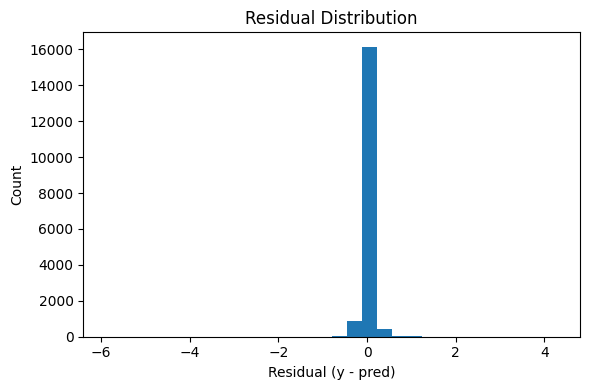

,RMSE,MAE,R2
시작_대여소_ID,,,
ST-1020,0.019371,0.017706,0.999142
ST-1023,0.017479,0.015662,0.999656
ST-1024,0.030003,0.011464,0.998230
ST-1025,0.034506,0.020561,0.998805
ST-1027,0.035361,0.022123,0.998381
...,...,...,...
ST-476,0.093222,0.058004,0.995603
ST-478,0.056394,0.044657,0.997406
ST-479,0.098536,0.060777,0.994184


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 예측/잔차 계산 (현재 reg, X_test, y_test가 있다고 가정)
pred = reg.predict(X_test)
resid = y_test.values - pred

# 1) 잔차 분포
plt.figure(figsize=(6,4))
plt.hist(resid, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual (y - pred)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2) 스테이션별 성능
test_df = flow_feat.iloc[split_idx:].copy()
test_df = test_df.assign(pred=pred, resid=resid)

def station_metrics(g):
    y_true = g['순유출입']
    y_pred = g['pred']
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return pd.Series({'RMSE': rmse, 'MAE': mae, 'R2': r2})

station_report = test_df.groupby('시작_대여소_ID').apply(station_metrics)
station_report


In [37]:
station = ['ST-1035','ST-454','ST-471']

# 테스트셋에서 지정 스테이션만
test_df = flow_feat.iloc[split_idx:].copy()
test_df = test_df.assign(pred=pred, resid=resid)
test_df = test_df[test_df['시작_대여소_ID'].isin(station)]

# 스테이션별 성능
station_report = test_df.groupby('시작_대여소_ID').apply(station_metrics)
station_report


,RMSE,MAE,R2
시작_대여소_ID,,,
ST-1035,0.165184,0.117217,0.995006
ST-454,0.377566,0.182363,0.987321
ST-471,0.075002,0.054721,0.997202
